In [1]:
import pandas as pd

In [2]:
#mdf = pd.read_excel('wong_data/many_mouse.xlsx')
#mdf = pd.read_csv('wong_data/mouse_downstream.csv')
#hdf = pd.read_csv('gers_data/human_downstream.csv')

mdf = pd.read_excel('wong_data/many_mouse.xlsx')
hdf = pd.read_csv('gers_data/human_downstream.csv')

In [3]:
mdf['upstream_gene'] = mdf['test_gRNAtarget'].str.upper()
mdf = mdf[mdf['upstream_gene'] != 'SREBF1']
mdf = mdf[mdf['upstream_gene'] == 'DPF2']
mdf

,test_gRNAtarget,testgene,n_ctrlcells,n_pertcells,glm_coef,glm_p,fdr,upstream_gene
20311,Dpf2,Xkr4,75879,2758,-0.064776,0.234218,0.670923,DPF2
20312,Dpf2,Gm19938,75879,2758,-0.132510,0.110171,0.513107,DPF2
20313,Dpf2,Rp1,75879,2758,-0.022650,0.882514,0.973959,DPF2
20314,Dpf2,Gm37323,75879,2758,-0.046362,0.951395,0.988493,DPF2
20315,Dpf2,Mrpl15,75879,2758,-0.023850,0.309701,0.732213,DPF2
...,...,...,...,...,...,...,...,...
41050,Dpf2,Tmlhe,75879,2758,-0.168133,0.243973,0.678327,DPF2
41051,Dpf2,CR974586.4,75879,2758,-1.916292,0.047828,0.359016,DPF2
41052,Dpf2,4933409K07Rik,75879,2758,-0.026738,0.869080,0.970543,DPF2
41053,Dpf2,CAAA01147332.1,75879,2758,-0.065146,0.651417,0.907749,DPF2


In [4]:
hdf = hdf[hdf['upstream_gene'] == 'DPF2-205']
hdf

,upstream_gene,idx,gene_names,num_cell,pvals_sig_adj,Significant,log2fc
21736,DPF2-205,87354,ENSG00000238009,277,0.363738,False,-1.028103
21737,DPF2-205,61670,ENSG00000241860,277,0.782561,False,-0.084769
21738,DPF2-205,77166,ENSG00000286448,277,0.402908,False,-0.670760
21739,DPF2-205,71886,ENSG00000290385,277,0.589998,False,-0.117941
21740,DPF2-205,74597,LINC01409,277,0.390366,False,-0.556438
...,...,...,...,...,...,...,...
43213,DPF2-205,82764,MT-CO3,277,0.377485,False,0.011742
43214,DPF2-205,63054,MT-ND4,277,0.382042,False,0.046018
43215,DPF2-205,62842,MT-ND5,277,0.413753,False,0.013370
43216,DPF2-205,73323,ENSG00000276256,277,0.385522,False,0.149980


In [5]:
human_genes = list(set(hdf['gene_names'].to_list()))
mouse_genes = list(set(mdf['testgene'].to_list()))  

In [6]:
sig_human_genes = list(set(hdf[hdf['pvals_sig_adj'] < 0.05]['gene_names']))
#sig_mouse_genes = list(set(mdf[mdf['glm_p'] < 0.05]['testgene']))
sig_mouse_genes = list(set(mdf[mdf['glm_p'] < 0.05]['testgene']))

In [7]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

mresults = gp.orth(
    query=mouse_genes,
    organism='mmusculus',  
    target='hsapiens',     
)

msresults = gp.orth(
    query=sig_mouse_genes,
    organism='mmusculus',  
    target='hsapiens',     
)

hresults = gp.convert(
    query=human_genes,
    organism='hsapiens',
    target_namespace='ENSG'
)

hsresults = gp.convert(
    query=sig_human_genes,
    organism='hsapiens',
    target_namespace='ENSG'
)

In [8]:
mlist = mresults[['ortholog_ensg']].values.tolist()
hlist = hresults[['converted']].values.tolist()
mslist = msresults[['ortholog_ensg']].values.tolist()
hslist = hsresults[['converted']].values.tolist()

GENE LIST COMPARISON REPORT
(1) Human present sig, Mouse present sig:       43
(2) Human present sig, Mouse present nonsig:    93
(3) Human present nonsig, Mouse present sig:    1954
(4) Human present nonsig, Mouse present nonsig: 10458
------------------------------------------------------------
(5) Human absent, Mouse present:                2017
(6) Human present, Mouse absent:                8729


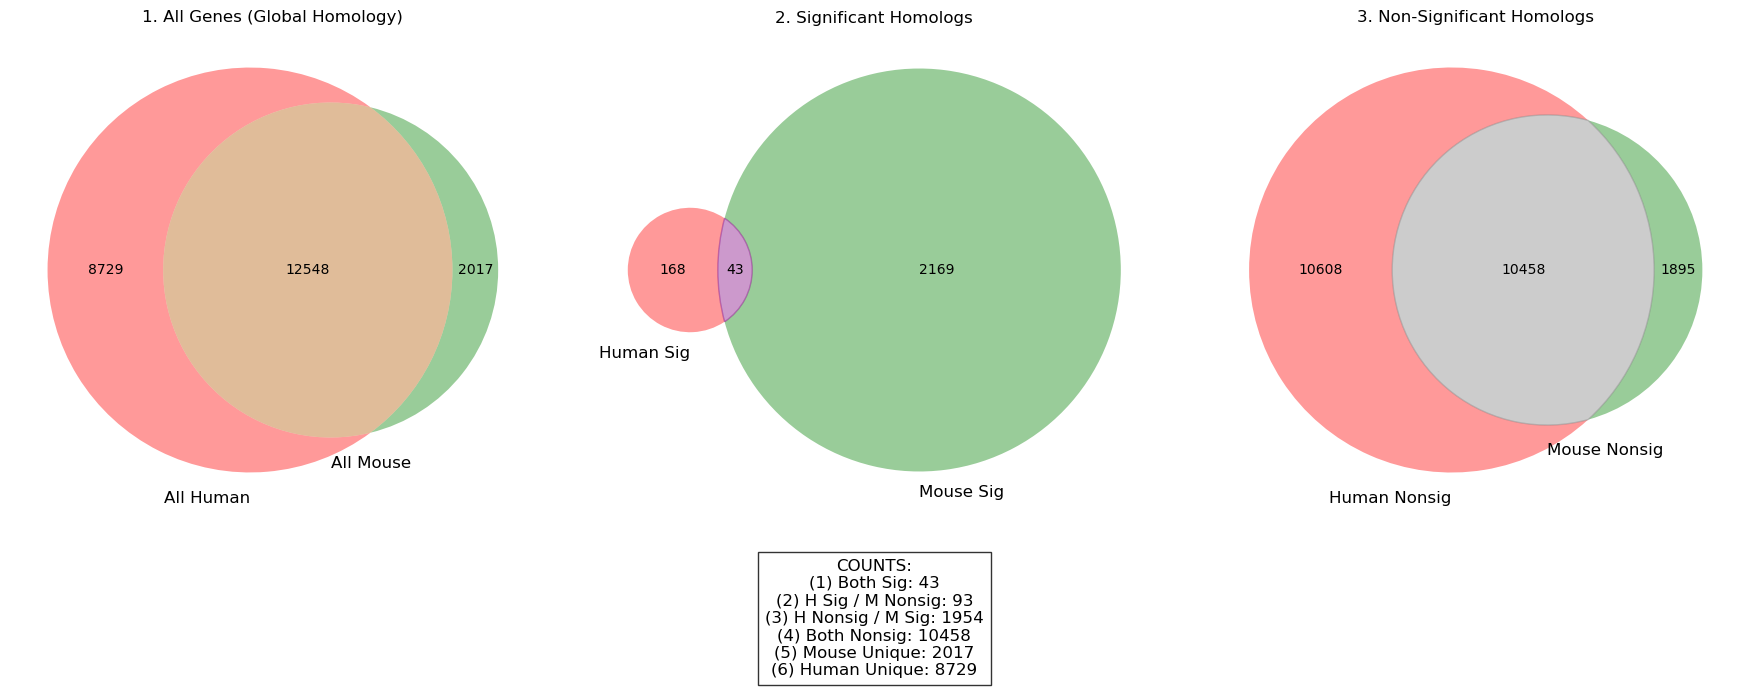

In [9]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

def clean_input_list(input_data):
    """
    Helper function to flatten lists of lists and ensure data are strings.
    Example: [['GeneA'], ['GeneB']] -> {'GeneA', 'GeneB'}
    """
    clean_set = set()
    for item in input_data:
        if isinstance(item, (list, tuple, pd.Series)):
            if len(item) > 0:
                clean_set.add(str(item[0]))
        else:
            clean_set.add(str(item))
    return clean_set

def compare_species_lists(mlist, hlist, mslist, hslist):
    """
    Generates 3 Venn diagrams and a detailed report for 6 specific gene categories.
    """
    # --- 1. DATA PREPARATION ---
    M_all = clean_input_list(mlist)
    H_all = clean_input_list(hlist)
    M_sig = clean_input_list(mslist)
    H_sig = clean_input_list(hslist)

    # Define the "Universe" of Homologs (Genes present in both)
    common_genes = M_all.intersection(H_all)
    
    # Define Non-Significant sets (All - Sig)
    M_nonsig = M_all - M_sig
    H_nonsig = H_all - H_sig

    # --- 2. CALCULATE THE 6 CATEGORIES ---
    
    # (1) Human present sig, Mouse present sig
    # (Intersection of Sig sets within Common genes)
    cat1 = (H_sig & M_sig) & common_genes
    
    # (2) Human present sig, Mouse present nonsig
    # (H is Sig, M is Nonsig, within Common)
    cat2 = (H_sig & M_nonsig) & common_genes
    
    # (3) Human present nonsig, Mouse present sig
    # (H is Nonsig, M is Sig, within Common)
    cat3 = (H_nonsig & M_sig) & common_genes
    
    # (4) Human present nonsig, Mouse present nonsig
    # (Both are Nonsig, within Common)
    cat4 = (H_nonsig & M_nonsig) & common_genes
    
    # (5) Human absent, Mouse present
    # (Strictly unique to Mouse list)
    cat5 = M_all - H_all
    
    # (6) Human present, Mouse absent
    # (Strictly unique to Human list)
    cat6 = H_all - M_all

    # --- 3. PLOTTING THE 3 VENN DIAGRAMS ---
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # DIAGRAM 1: GLOBAL OVERLAP (All Genes)
    # Visualizes Categories 5 and 6 (Species Unique) vs Homologs
    venn2([H_all, M_all], set_labels=('All Human', 'All Mouse'), ax=axes[0])
    axes[0].set_title("1. All Genes (Global Homology)")
    
    # DIAGRAM 2: SIGNIFICANT HOMOLOGS
    # Visualizes Categories 1, 2, and 3
    # We restrict this Venn to ONLY common genes to make the numbers match your logic
    h_sig_common = H_sig & common_genes
    m_sig_common = M_sig & common_genes
    
    #v2 = venn2([h_sig_common, m_sig_common], set_labels=('Human Sig', 'Mouse Sig'), ax=axes[1])
    v2 = venn2([H_sig, M_sig], set_labels=('Human Sig', 'Mouse Sig'), ax=axes[1])
    axes[1].set_title("2. Significant Homologs")
    # Color customization for clarity
    if v2.get_patch_by_id('11'): v2.get_patch_by_id('11').set_color('purple')
    
    # DIAGRAM 3: NON-SIGNIFICANT HOMOLOGS
    # Visualizes Category 4 (and complements)
    h_nonsig_common = H_nonsig & common_genes
    m_nonsig_common = M_nonsig & common_genes
    
    #v3 = venn2([h_nonsig_common, m_nonsig_common], set_labels=('Human Nonsig', 'Mouse Nonsig'), ax=axes[2])
    v3 = venn2([H_nonsig, M_nonsig], set_labels=('Human Nonsig', 'Mouse Nonsig'), ax=axes[2])
    axes[2].set_title("3. Non-Significant Homologs")
    if v3.get_patch_by_id('11'): v3.get_patch_by_id('11').set_color('gray')

    # --- 4. PRINTING THE REPORT ---
    
    print("="*60)
    print("GENE LIST COMPARISON REPORT")
    print("="*60)
    print(f"(1) Human present sig, Mouse present sig:       {len(cat1)}")
    print(f"(2) Human present sig, Mouse present nonsig:    {len(cat2)}")
    print(f"(3) Human present nonsig, Mouse present sig:    {len(cat3)}")
    print(f"(4) Human present nonsig, Mouse present nonsig: {len(cat4)}")
    print("-" * 60)
    print(f"(5) Human absent, Mouse present:                {len(cat5)}")
    print(f"(6) Human present, Mouse absent:                {len(cat6)}")
    print("="*60)
    
    # Add text box to the plot image as well
    stats_text = (
        f"COUNTS:\n"
        f"(1) Both Sig: {len(cat1)}\n"
        f"(2) H Sig / M Nonsig: {len(cat2)}\n"
        f"(3) H Nonsig / M Sig: {len(cat3)}\n"
        f"(4) Both Nonsig: {len(cat4)}\n"
        f"(5) Mouse Unique: {len(cat5)}\n"
        f"(6) Human Unique: {len(cat6)}"
    )
    plt.figtext(0.5, -0.1, stats_text, ha="center", fontsize=12, 
                bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    plt.tight_layout(rect=[0, 0.15, 1, 1]) # Make room for text at bottom
    plt.savefig('venn_DPF2-205.png')
    plt.show()



# Run the function
compare_species_lists(mlist, hlist, mslist, hslist)